QUESTION 1: Lagrange and Spline Interpolation

Given Data Points:
  (1, 1)
  (2, 3)
  (3, 5)
  (4, 8)
  (5, 5)
  (6, 2)

1. LAGRANGE INTERPOLATION

Lagrange Polynomial Coefficients (highest to lowest degree):
  x^5: 0.175000
  x^4: -2.958333
  x^3: 18.375000
  x^2: -52.041667
  x^1: 68.450000
  x^0: -31.000000

Lagrange Polynomial (Symbolic Form):
  P(x) = 0.175*x**5 - 2.95833333333333*x**4 + 18.375*x**3 - 52.0416666666667*x**2 + 68.45*x - 31.0

Lagrange Polynomial (Expanded Form):
  P(x) = 0.175*x**5 - 2.95833333333333*x**4 + 18.375*x**3 - 52.0416666666667*x**2 + 68.45*x - 31.0

2. CUBIC SPLINE INTERPOLATION

Cubic Spline Coefficients for each interval:
Format: S_i(x) = a_i + b_i*(x-x_i) + c_i*(x-x_i)^2 + d_i*(x-x_i)^3

Interval [1, 2]:
  S_0(x) = 1.000000 + 2.186603*(x-1) + 0.000000*(x-1)^2 + -0.186603*(x-1)^3
  Expanded: S_0(x) = -0.186602870813397*x**3 + 0.559808612440191*x**2 + 1.62679425837321*x - 1.0

Interval [2, 3]:
  S_1(x) = 3.000000 + 1.626794*(x-2) + -0.559809*(x-2)^2 + 0.

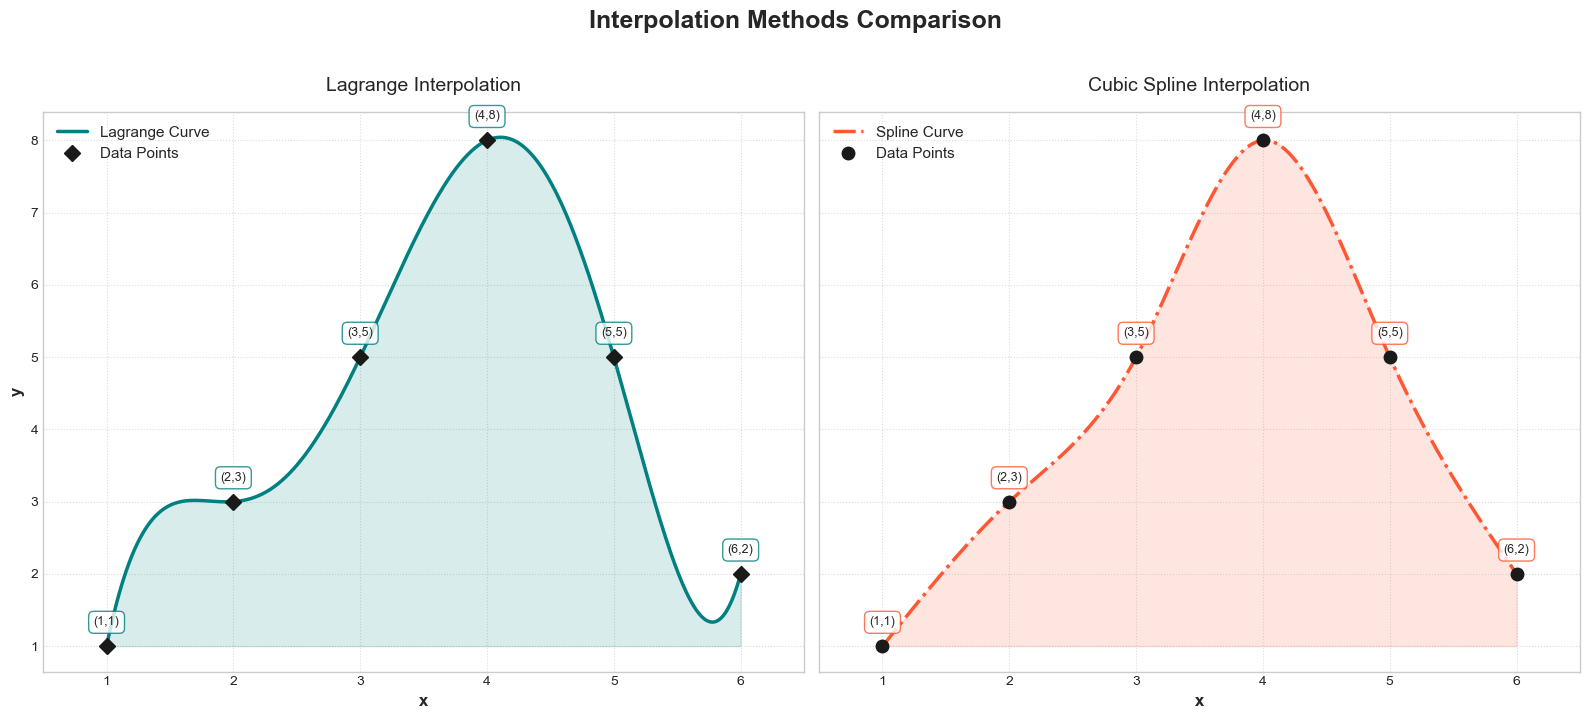


4. VERIFICATION: Values at Original Points
x         Original       Lagrange       Spline         
----------------------------------------------------------------------
1         1.000000       1.000000       1.000000       
2         3.000000       3.000000       3.000000       
3         5.000000       5.000000       5.000000       
4         8.000000       8.000000       8.000000       
5         5.000000       5.000000       5.000000       
6         2.000000       2.000000       2.000000       

INTERPOLATION COMPLETED SUCCESSFULLY


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline
import sympy as sp

# Given data points
x_points = np.array([1, 2, 3, 4, 5, 6])
y_points = np.array([1, 3, 5, 8, 5, 2])

print("="*70)
print("QUESTION 1: Lagrange and Spline Interpolation")
print("="*70)
print(f"\nGiven Data Points:")
for i in range(len(x_points)):
    print(f"  ({x_points[i]}, {y_points[i]})")

# ============================================================================
# 1. Lagrange Interpolation
# ============================================================================
print("\n" + "="*70)
print("1. LAGRANGE INTERPOLATION")
print("="*70)

# Using scipy's lagrange function
lagrange_poly = lagrange(x_points, y_points)

# Extract coefficients (from highest degree to constant)
lagrange_coeffs = lagrange_poly.coefficients

print("\nLagrange Polynomial Coefficients (highest to lowest degree):")
for i, coeff in enumerate(lagrange_coeffs):
    degree = len(lagrange_coeffs) - 1 - i
    print(f"  x^{degree}: {coeff:.6f}")

# Get symbolic representation using sympy
x_sym = sp.Symbol('x')
lagrange_symbolic = sum(coeff * x_sym**(len(lagrange_coeffs)-1-i) 
                       for i, coeff in enumerate(lagrange_coeffs))
lagrange_simplified = sp.simplify(lagrange_symbolic)

print(f"\nLagrange Polynomial (Symbolic Form):")
print(f"  P(x) = {lagrange_simplified}")

# Expanded form
lagrange_expanded = sp.expand(lagrange_simplified)
print(f"\nLagrange Polynomial (Expanded Form):")
print(f"  P(x) = {lagrange_expanded}")

# ============================================================================
# 2. Cubic Spline Interpolation
# ============================================================================
print("\n" + "="*70)
print("2. CUBIC SPLINE INTERPOLATION")
print("="*70)

# Using scipy's CubicSpline
spline = CubicSpline(x_points, y_points, bc_type='natural')

print("\nCubic Spline Coefficients for each interval:")
print("Format: S_i(x) = a_i + b_i*(x-x_i) + c_i*(x-x_i)^2 + d_i*(x-x_i)^3")
print()

for i in range(len(x_points) - 1):
    a = spline.c[3, i]  # coefficient of (x-xi)^0
    b = spline.c[2, i]  # coefficient of (x-xi)^1
    c = spline.c[1, i]  # coefficient of (x-xi)^2
    d = spline.c[0, i]  # coefficient of (x-xi)^3
    
    print(f"Interval [{x_points[i]}, {x_points[i+1]}]:")
    print(f"  S_{i}(x) = {a:.6f} + {b:.6f}*(x-{x_points[i]}) + " + 
          f"{c:.6f}*(x-{x_points[i]})^2 + {d:.6f}*(x-{x_points[i]})^3")
    
    # Expand the polynomial for this interval
    x_sym = sp.Symbol('x')
    xi = x_points[i]
    spline_piece = a + b*(x_sym - xi) + c*(x_sym - xi)**2 + d*(x_sym - xi)**3
    spline_expanded = sp.expand(spline_piece)
    print(f"  Expanded: S_{i}(x) = {spline_expanded}")
    print()

# ============================================================================
# 3. Visualization (MODIFIED FOR NEW LOOK)
# ============================================================================
print("="*70)
print("3. PLOTTING RESULTS (MODERN & SIDE-BY-SIDE)")
print("="*70)

# Generate fine grid for smooth curves
x_fine = np.linspace(x_points[0], x_points[-1], 500)

# Evaluate interpolations
y_lagrange = lagrange_poly(x_fine)
y_spline = spline(x_fine)

# Use a cleaner background style (if available)
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('ggplot')

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('Interpolation Methods Comparison', fontsize=18, fontweight='bold', y=1.02)

# ----- Subplot 1: Lagrange Interpolation -----
color1 = '#008080'  # Teal
ax1.plot(x_fine, y_lagrange, color=color1, linewidth=2.5, label='Lagrange Curve')
ax1.fill_between(x_fine, y_lagrange, min(min(y_lagrange), min(y_spline)), color=color1, alpha=0.15)
ax1.plot(x_points, y_points, 'D', color='#1a1a1a', markersize=8, label='Data Points', zorder=5)

ax1.set_title('Lagrange Interpolation', fontsize=14, pad=15)
ax1.set_xlabel('x', fontsize=12, fontweight='bold')
ax1.set_ylabel('y', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.set_xlim([0.5, 6.5])

# Annotations for Lagrange
for i in range(len(x_points)):
    ax1.annotate(f'({x_points[i]},{y_points[i]})', 
                 xy=(x_points[i], y_points[i]), 
                 xytext=(0, 15), textcoords='offset points', ha='center',
                 fontsize=9, bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=color1, lw=1, alpha=0.8))

# ----- Subplot 2: Cubic Spline Interpolation -----
color2 = '#FF5733'  # Coral/Orange
ax2.plot(x_fine, y_spline, color=color2, linewidth=2.5, linestyle='-.', label='Spline Curve')
ax2.fill_between(x_fine, y_spline, min(min(y_lagrange), min(y_spline)), color=color2, alpha=0.15)
ax2.plot(x_points, y_points, 'o', color='#1a1a1a', markersize=9, label='Data Points', zorder=5)

ax2.set_title('Cubic Spline Interpolation', fontsize=14, pad=15)
ax2.set_xlabel('x', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11, loc='upper left')
ax2.set_xlim([0.5, 6.5])

# Annotations for Spline
for i in range(len(x_points)):
    ax2.annotate(f'({x_points[i]},{y_points[i]})', 
                 xy=(x_points[i], y_points[i]), 
                 xytext=(0, 15), textcoords='offset points', ha='center',
                 fontsize=9, bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=color2, lw=1, alpha=0.8))

# Global grid and layout adjustments
ax1.grid(True, linestyle=':', alpha=0.7)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()

# Save and Show
import os
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/question1_interpolation_v2.png', dpi=300, bbox_inches='tight')
print("\nPlot saved to: ../outputs/figures/question1_interpolation_v2.png")
plt.show()

# ============================================================================
# 4. Numerical Comparison
# ============================================================================
print("\n" + "="*70)
print("4. VERIFICATION: Values at Original Points")
print("="*70)
print(f"{'x':<10}{'Original':<15}{'Lagrange':<15}{'Spline':<15}")
print("-"*70)

for i in range(len(x_points)):
    x_val = x_points[i]
    y_orig = y_points[i]
    y_lag = lagrange_poly(x_val)
    y_spl = spline(x_val)
    print(f"{x_val:<10}{y_orig:<15.6f}{y_lag:<15.6f}{y_spl:<15.6f}")

print("\n" + "="*72)
print("INTERPOLATION COMPLETED SUCCESSFULLY")
print("="*72)
